In [3]:
# Cell 1 — Initialize SLM with Kunal's calibrated 759-nm LUT

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.meadowlark import Meadowlark


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

KUNAL_LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM"
    r"\LUT from Kunal - B grade SLM"
    r"\759nm_KS_global_20260811.lut"
)


# ------------------------------------------------------------
# Initialize SLM
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(KUNAL_LUT_PATH),
    wav_um=0.759,
    verbose=True,
)


print("\n=== SLM ready ===")
print("Name       :", slm.name)
print("Shape      :", slm.shape)
print("Bit depth  :", slm.bitdepth)
print("Wavelength :", slm.wav_um, "um")
print("Pixel pitch:", slm.pitch_um, "um")
print("LUT        :", KUNAL_LUT_PATH)

Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...
=== SLM ready ===
Name       : Meadowlark HDMI
Shape      : (1200, 1920)
Bit depth  : 8
Wavelength : 0.759 um
Pixel pitch: [8. 8.] um
LUT        : C:\Users\admin\Desktop\Projects\SLM\LUT from Kunal - B grade SLM\759nm_KS_global_20260811.lut


=== Blazed grating ===
Pitch                  : 16 pixels
Physical period        : 128 um
Number of phase levels : 16
Phase min              : 0.0 rad
Phase max              : 5.890486225480862 rad


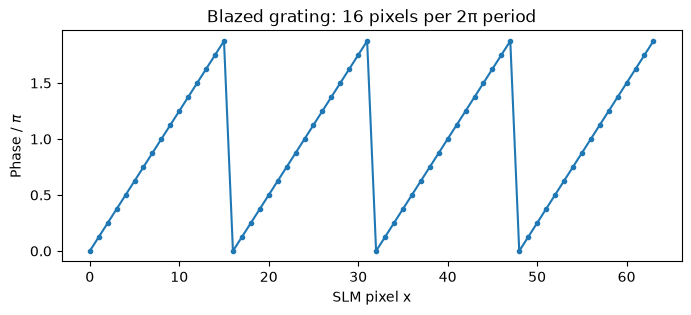


Blazed grating written to SLM.


In [ ]:
# Cell 2 — Generate and display a blazed grating

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CHANGE ONLY THIS NUMBER
# ============================================================

pitch_px = 2      # allowed: 2, 4, 6, ..., 32


# ============================================================
# Generate 0 -> 2π phase ramp
# ============================================================

ny, nx = slm.shape

x = np.arange(nx)

# One complete 0 -> 2π ramp every pitch_px pixels
phase_line = 2 * np.pi * (x % pitch_px) / pitch_px

# Repeat along y -> vertical stripes -> diffraction along x
phase_grating = np.tile(
    phase_line,
    (ny, 1)
)


# ============================================================
# Diagnostics
# ============================================================

print("=== Blazed grating ===")
print("Pitch                  :", pitch_px, "pixels")
print("Physical period        :", pitch_px * 8, "um")
print("Number of phase levels :", len(np.unique(phase_line)))
print("Phase min              :", phase_grating.min(), "rad")
print("Phase max              :", phase_grating.max(), "rad")


# ============================================================
# Plot 4 periods
# ============================================================

plt.figure(figsize=(8, 3))

plt.plot(
    x[:4 * pitch_px],
    phase_line[:4 * pitch_px] / np.pi,
    ".-",
)

plt.xlabel("SLM pixel x")
plt.ylabel(r"Phase / $\pi$")
plt.title(f"Blazed grating: {pitch_px} pixels per 2π period")

plt.show()


# ============================================================
# Send phase to SLM
#
# IMPORTANT:
# This is a float phase array in radians.
# slmsuite converts it using your calibrated LUT.
# ============================================================

slm.set_phase(
    phase_grating,
    settle=True,
)

print("\nBlazed grating written to SLM.")